<a href="https://colab.research.google.com/github/umeshmethre/Data-Science/blob/main/ML_Algorithm_Comparison_Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Performance Comparison of Machine Learning Algorithms

# Performance Comparison of Machine Learning Algorithms on Kaggle Dataset

---



## Step 1: Import Libraries



In [175]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Description
Dataset: Titanic Dataset  
Target: Survived  
Type: Classification

## Step 2: Load Dataset

In [203]:
df = pd.read_csv("/content/Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [178]:
df = df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [179]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0
Embarked,2


In [180]:
df.dropna(inplace=True)

## Step 3: Data Preprocessing

In [181]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

## Step 4: Train Test Split

In [182]:
from sklearn.model_selection import train_test_split

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Step 5: Apply Algorithms

In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

### Logistic Regression

In [184]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

### K-Nearest Neighbors (KNN)

In [185]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

### Decision Tree

In [186]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

## Step 6: Model Evaluation

In [187]:
from sklearn.metrics import accuracy_score

In [188]:
lr_acc = accuracy_score(y_test, lr_pred)
knn_acc = accuracy_score(y_test, knn_pred)
dt_acc = accuracy_score(y_test, dt_pred)

print("Logistic Regression:", lr_acc)
print("KNN:", knn_acc)
print("Decision Tree:", dt_acc)

Logistic Regression: 0.7972027972027972
KNN: 0.7062937062937062
Decision Tree: 0.6993006993006993


In [189]:
results = {
    "Logistic Regression": lr_acc,
    "KNN": knn_acc,
    "Decision Tree": dt_acc
}

results

{'Logistic Regression': 0.7972027972027972,
 'KNN': 0.7062937062937062,
 'Decision Tree': 0.6993006993006993}

## Performance Graph

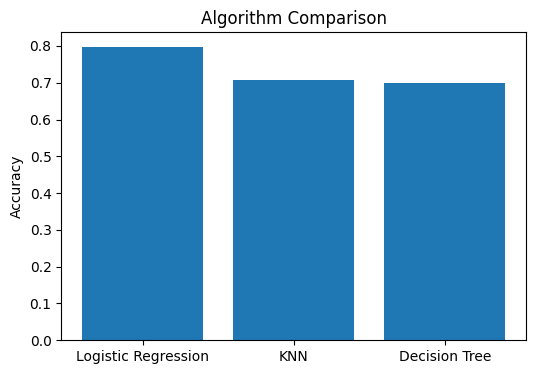

In [190]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(results.keys(), results.values())
plt.title("Algorithm Comparison")
plt.ylabel("Accuracy")
plt.show()

In [191]:
best = max(results, key=results.get)
print("Best Algorithm:", best)

Best Algorithm: Logistic Regression


### Random Forest

In [192]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [193]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)


### SVM

In [194]:
svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [195]:
from sklearn.metrics import accuracy_score, f1_score


In [196]:
lr_acc = accuracy_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
svm_acc = accuracy_score(y_test, svm_pred)

lr_f1 = f1_score(y_test, lr_pred)
rf_f1 = f1_score(y_test, rf_pred)
svm_f1 = f1_score(y_test, svm_pred)

print("Logistic Regression:", lr_acc, lr_f1)
print("Random Forest:", rf_acc, rf_f1)
print("SVM:", svm_acc, svm_f1)

Logistic Regression: 0.7972027972027972 0.7387387387387387
Random Forest: 0.7902097902097902 0.7457627118644068
SVM: 0.6363636363636364 0.48


## Comparison Table

In [197]:
import pandas as pd

comparison = pd.DataFrame({
    "Algorithm": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [lr_acc, rf_acc, svm_acc],
    "F1 Score": [lr_f1, rf_f1, svm_f1]
})

comparison

,Algorithm,Accuracy,F1 Score
0,Logistic Regression,0.797203,0.738739
1,Random Forest,0.790210,0.745763
2,SVM,0.636364,0.480000


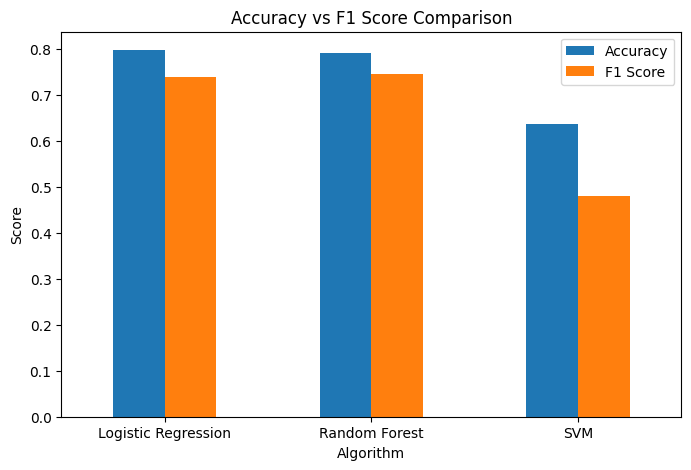

In [198]:
comparison.plot(
    x="Algorithm",
    y=["Accuracy", "F1 Score"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Accuracy vs F1 Score Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## Confusion Matrix

In [199]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

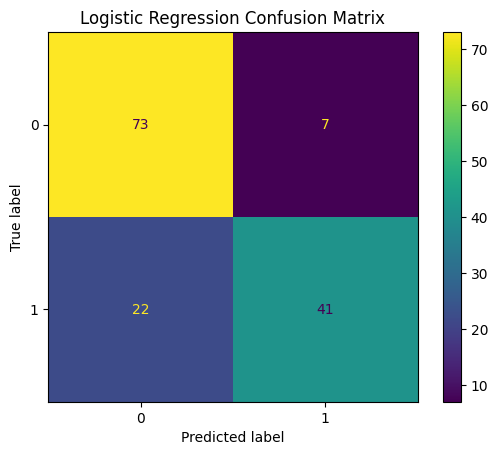

In [200]:
cm_lr = confusion_matrix(y_test, lr_pred)

ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

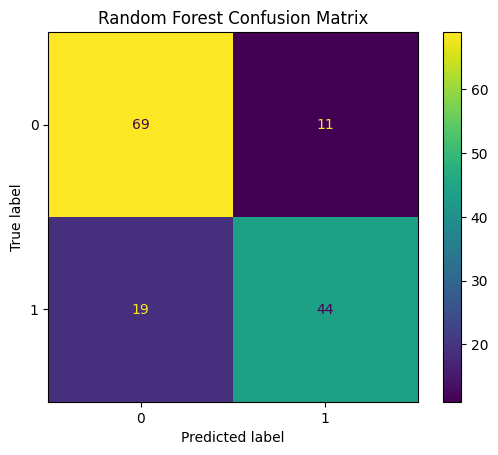

In [201]:
cm_rf = confusion_matrix(y_test, rf_pred)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

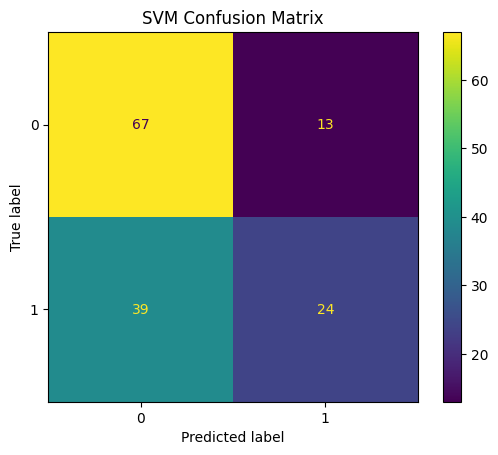

In [202]:
cm_svm = confusion_matrix(y_test, svm_pred)

ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

## Conclusion
Random Forest algorithm performed best based on accuracy and F1 score.